In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded!")

Libraries loaded!


In [ ]:
# Base water requirements in mm/day (from FAO irrigation manual)
crop_water_base = {
    'rice':        8.0,
    'maize':       5.5,
    'wheat':       4.5,
    'sugarcane':   7.0,
    'cotton':      6.0,
    'soybean':     5.0,
    'potato':      5.5,
    'tomato':      5.0,
    'onion':       4.0,
    'banana':      6.5,
    'mango':       4.5,
    'grapes':      5.5,
    'chickpea':    3.5,
    'lentil':      3.0,
    'sunflower':   5.0,
}

# Soil drainage factors
soil_drainage = {
    'sandy':  1.35,   # drains fast — needs more water
    'loamy':  1.00,   # balanced
    'black':  0.85,   # retains water well
    'red':    1.15,   # moderate drainage
    'clayey': 0.75,   # retains most water
}

# Growth stage factors
growth_stage_factor = {
    'seedling':   0.4,
    'vegetative': 0.8,
    'flowering':  1.2,
    'maturity':   0.9,
    'harvest':    0.5,
}

crops      = list(crop_water_base.keys())
soils      = list(soil_drainage.keys())
stages     = list(growth_stage_factor.keys())

print(f"Crops: {len(crops)}")
print(f"Soil types: {len(soils)}")
print(f"Growth stages: {len(stages)}")

Crops: 15
Soil types: 5
Growth stages: 5


In [ ]:
n_samples = 10000
records   = []

for _ in range(n_samples):
    crop         = np.random.choice(crops)
    soil         = np.random.choice(soils)
    stage        = np.random.choice(stages)
    temperature  = np.random.uniform(10, 45)
    humidity     = np.random.uniform(20, 95)
    rainfall     = np.random.uniform(0, 25)
    wind_speed   = np.random.uniform(0, 15)
    sunshine_hrs = np.random.uniform(4, 12)

    # FAO Penman-Monteith simplified formula
    # Higher temp + wind + sunshine = more evaporation = more water needed
    et0 = (
        0.0023 * (temperature + 17.8) *
        (sunshine_hrs ** 0.5) *
        (1 + wind_speed / 20)
    )

    # Base crop water need
    base_need = crop_water_base[crop]

    # Apply all factors
    water_req = (
        base_need *
        growth_stage_factor[stage] *
        soil_drainage[soil] *
        (1 + (temperature - 25) * 0.02) *    # temp adjustment
        (1 - (humidity - 50)   * 0.003) *    # humidity adjustment
        max(0.1, 1 - rainfall / 30)           # rainfall reduces need
    )

    # Add realistic noise
    water_req += np.random.normal(0, 0.2)
    water_req  = max(0.5, round(water_req, 2))

    # Irrigation needed = yes if water_req > rainfall contribution
    irrigation_needed = int(water_req > (rainfall * 0.1))

    records.append({
        'crop':              crop,
        'soil_type':         soil,
        'growth_stage':      stage,
        'temperature':       round(temperature,  1),
        'humidity':          round(humidity,      1),
        'rainfall':          round(rainfall,      1),
        'wind_speed':        round(wind_speed,    1),
        'sunshine_hours':    round(sunshine_hrs,  1),
        'water_requirement': water_req,
        'irrigation_needed': irrigation_needed,
    })

df = pd.DataFrame(records)
print(f"Dataset generated: {df.shape}")
df.head(10)

Dataset generated: (10000, 10)


,crop,soil_type,growth_stage,temperature,humidity,rainfall,wind_speed,sunshine_hours,water_requirement,irrigation_needed
0,potato,red,harvest,16.4,78.5,14.9,6.7,4.8,0.80,0
1,tomato,black,harvest,43.9,82.4,5.3,2.7,5.5,2.08,1
2,grapes,loamy,harvest,25.1,41.8,15.3,2.1,6.3,1.24,0
3,sunflower,black,maturity,28.0,64.4,1.2,9.1,5.4,3.30,1
4,potato,loamy,maturity,43.0,62.2,9.6,0.2,5.8,4.56,1
5,grapes,clayey,flowering,41.8,39.4,16.6,4.7,8.2,2.84,1
6,banana,red,harvest,43.9,78.1,23.5,13.4,8.8,0.82,0
7,maize,clayey,vegetative,43.8,65.5,6.9,4.4,5.3,3.02,1
8,onion,sandy,seedling,17.0,20.4,20.4,10.6,9.8,0.50,0
9,potato,sandy,maturity,21.6,24.8,7.8,4.9,9.8,4.90,1


Water Requirement Stats:
count    10000.000000
mean         2.421957
std          1.747002
min          0.500000
25%          1.150000
50%          1.960000
75%          3.190000
max         15.470000
Name: water_requirement, dtype: float64

Average water need by crop:
crop
rice         3.608050
sugarcane    3.252715
banana       2.857137
cotton       2.831962
maize        2.657360
grapes       2.579509
potato       2.530812
soybean      2.315168
sunflower    2.314781
tomato       2.248882
wheat        2.119056
mango        2.069925
onion        1.873164
chickpea     1.610100
lentil       1.413051
Name: water_requirement, dtype: float64


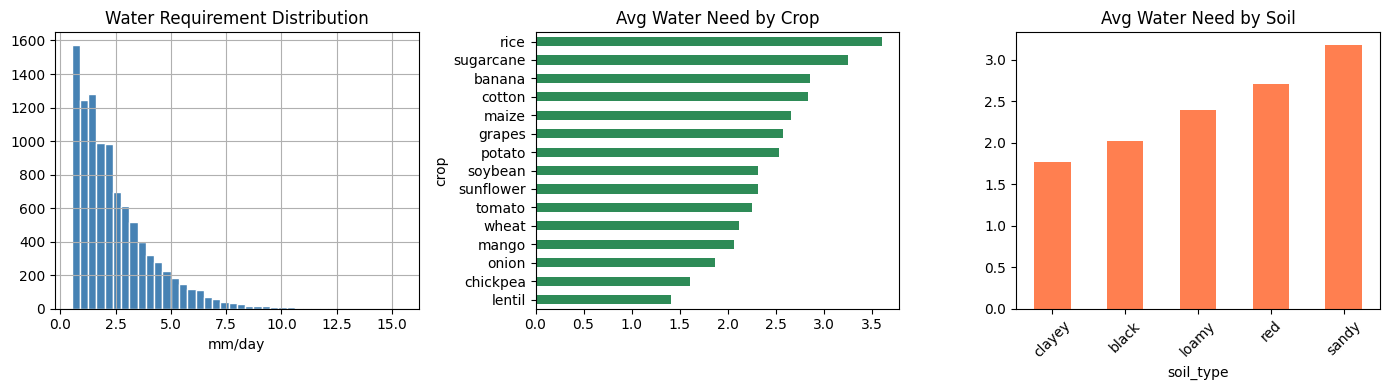

In [ ]:
print("Water Requirement Stats:")
print(df['water_requirement'].describe())

print("\nAverage water need by crop:")
print(df.groupby('crop')['water_requirement'].mean().sort_values(ascending=False))

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
df['water_requirement'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Water Requirement Distribution')
plt.xlabel('mm/day')

plt.subplot(1, 3, 2)
df.groupby('crop')['water_requirement'].mean().sort_values().plot(kind='barh', color='seagreen')
plt.title('Avg Water Need by Crop')

plt.subplot(1, 3, 3)
df.groupby('soil_type')['water_requirement'].mean().sort_values().plot(kind='bar', color='coral')
plt.title('Avg Water Need by Soil')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df_model = df.copy()

# Encode categorical columns
le_crop  = LabelEncoder()
le_soil  = LabelEncoder()
le_stage = LabelEncoder()

df_model['crop']         = le_crop.fit_transform(df['crop'])
df_model['soil_type']    = le_soil.fit_transform(df['soil_type'])
df_model['growth_stage'] = le_stage.fit_transform(df['growth_stage'])

# Features and target
feature_cols = [
    'crop', 'soil_type', 'growth_stage',
    'temperature', 'humidity', 'rainfall',
    'wind_speed', 'sunshine_hours'
]

X = df_model[feature_cols]
y = df_model['water_requirement']

# Scale features
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Features:         {feature_cols}")

Training samples: 8000
Testing samples:  2000
Features:         ['crop', 'soil_type', 'growth_stage', 'temperature', 'humidity', 'rainfall', 'wind_speed', 'sunshine_hours']


Train model


In [ ]:
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    min_samples_split=5,
    random_state=42
)

print("Training model...")
model.fit(X_train, y_train)
print("Model trained!")

Training model...
Model trained!


 R² Score:  0.9555  (closer to 1.0 = better)
 MAE:       0.2615 mm/day error on average


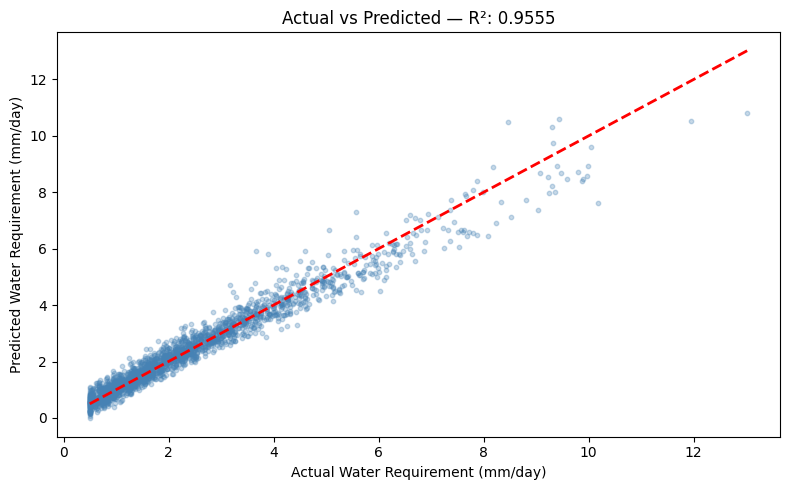

In [ ]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f" R² Score:  {r2:.4f}  (closer to 1.0 = better)")
print(f" MAE:       {mae:.4f} mm/day error on average")

# Plot predictions vs actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Water Requirement (mm/day)')
plt.ylabel('Predicted Water Requirement (mm/day)')
plt.title(f'Actual vs Predicted — R²: {r2:.4f}')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

shutil.copy(
    'irrigation_model.pkl',
    '/content/drive/MyDrive/FarmAI/irrigation_model.pkl'
)

'/content/drive/MyDrive/FarmAI/irrigation_model.pkl'

In [ ]:
model_data = {
    'model':          model,
    'scaler':         scaler,
    'le_crop':        le_crop,
    'le_soil':        le_soil,
    'le_stage':       le_stage,
    'feature_cols':   feature_cols,
    'crops':          crops,
    'soils':          soils,
    'stages':         stages,
    'crop_water_base': crop_water_base,
}

with open('irrigation_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Model saved!")

# Backup to Drive
import shutil
shutil.copy(
    'irrigation_model.pkl',
    '/content/drive/MyDrive/FarmAI/irrigation_model.pkl'
)
print("Backed up to Google Drive!")

Model saved!
Backed up to Google Drive!


In [ ]:
from google.colab import files
files.download('irrigation_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
